In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick


In [2]:
# Constants
parent_folder  = "results-test-small"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = True

Found 720 results


In [3]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))
zonia_palette = sns.color_palette(["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2", "#DEEEFF"])

# COLORI PER I GRAFICI (e.g., barre)
# #1B2D41 #466C82 #87A0B3 #D1E1F2
# COLORE PER ACCENTO (e.g., intervallo di confidenza)
# #A8D5BA

# https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4

# plt.rcParams.keys()

In [4]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    _df['Arrival'] = _params[7]
    _df['beta'] = float(_params[8])
    _df['Ratio Malicious Oracles'] = float(_params[9])
    # Local Processing
    
    if True or ((float(_params[8]) == 1.0 and float(_params[3]) == 0.5)):
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


  0%|          | 0/720 [00:00<?, ?it/s]

100%|██████████| 720/720 [00:05<00:00, 139.67it/s]


We ended up with 43121 rows


,Epoch,sources,malign,ban_sources,ban_malign,consensus,rep_benign,rep_malign,rep_min,ratio_malign,alpha,tolerance,repetition,Algorithm,Arrival,beta,Ratio Malicious Oracles
0,0,100,20,0,0,24.858049,0.021685,0.000000,-0.6,0.2,0.5,3.0,11.0,1.0,bursty,0.9,0.0
1,1,100,20,0,0,24.709301,0.038361,0.000000,-0.6,0.2,0.5,3.0,11.0,1.0,bursty,0.9,0.0
2,2,100,20,0,0,24.951434,0.056639,0.000000,-0.6,0.2,0.5,3.0,11.0,1.0,bursty,0.9,0.0
3,3,100,20,0,0,24.972238,0.074199,0.000000,-0.6,0.2,0.5,3.0,11.0,1.0,bursty,0.9,0.0
4,4,100,20,0,0,24.994601,0.089659,0.000000,-0.6,0.2,0.5,3.0,11.0,1.0,bursty,0.9,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799995,2995,100,20,0,0,25.002822,0.556746,-0.560787,-0.4,0.2,0.5,3.0,12.0,0.0,bursty,0.9,0.0
1799996,2996,100,20,0,0,24.647806,0.558173,-0.563618,-0.4,0.2,0.5,3.0,12.0,0.0,bursty,0.9,0.0
1799997,2997,100,20,0,0,24.895815,0.565553,-0.563618,-0.4,0.2,0.5,3.0,12.0,0.0,bursty,0.9,0.0
1799998,2998,100,20,0,0,25.016373,0.565290,-0.563618,-0.4,0.2,0.5,3.0,12.0,0.0,bursty,0.9,0.0


In [5]:
# Calculate Precision and Recall
print("Calculate precision and recall")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df['Consensus Accuracy'] = df.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

#df_good = df.drop(df[df['Consensus Accuracy'] == 0].index)


Calculate precision and recall
Recall done
Precision done
Consensus Accuracy done


In [6]:
# Reduce dataset for tests XXX
df_tail = df.drop(df[(df['Epoch'] < 2000)].index)
df_goodo = df.drop(df[(df['Ratio Malicious Oracles'] != 0.0)].index)
df_goodo2 = df_tail.drop(df_tail[(df_tail['Ratio Malicious Oracles'] != 0.0)].index)
df_def = df_goodo.drop(df_goodo[(df_goodo.Algorithm != 2)].index) # This is only considering our algorithm
#df_endtime = df_def.drop(df_def[(df_def.Epoch < 39)].index) # This is only conisdering the very last stage of the simulation,rather than evry single epoch

#df_endtime


In [97]:
# df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)

#df_def
#df_def['rep_min'].unique()

array([-0.8, -0.2, -0.6, -0.4])

In [98]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

Doing min_rep_rec_over_time.png


/tmp/ipykernel_5922/1380979856.py:7: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette)


KeyboardInterrupt: 

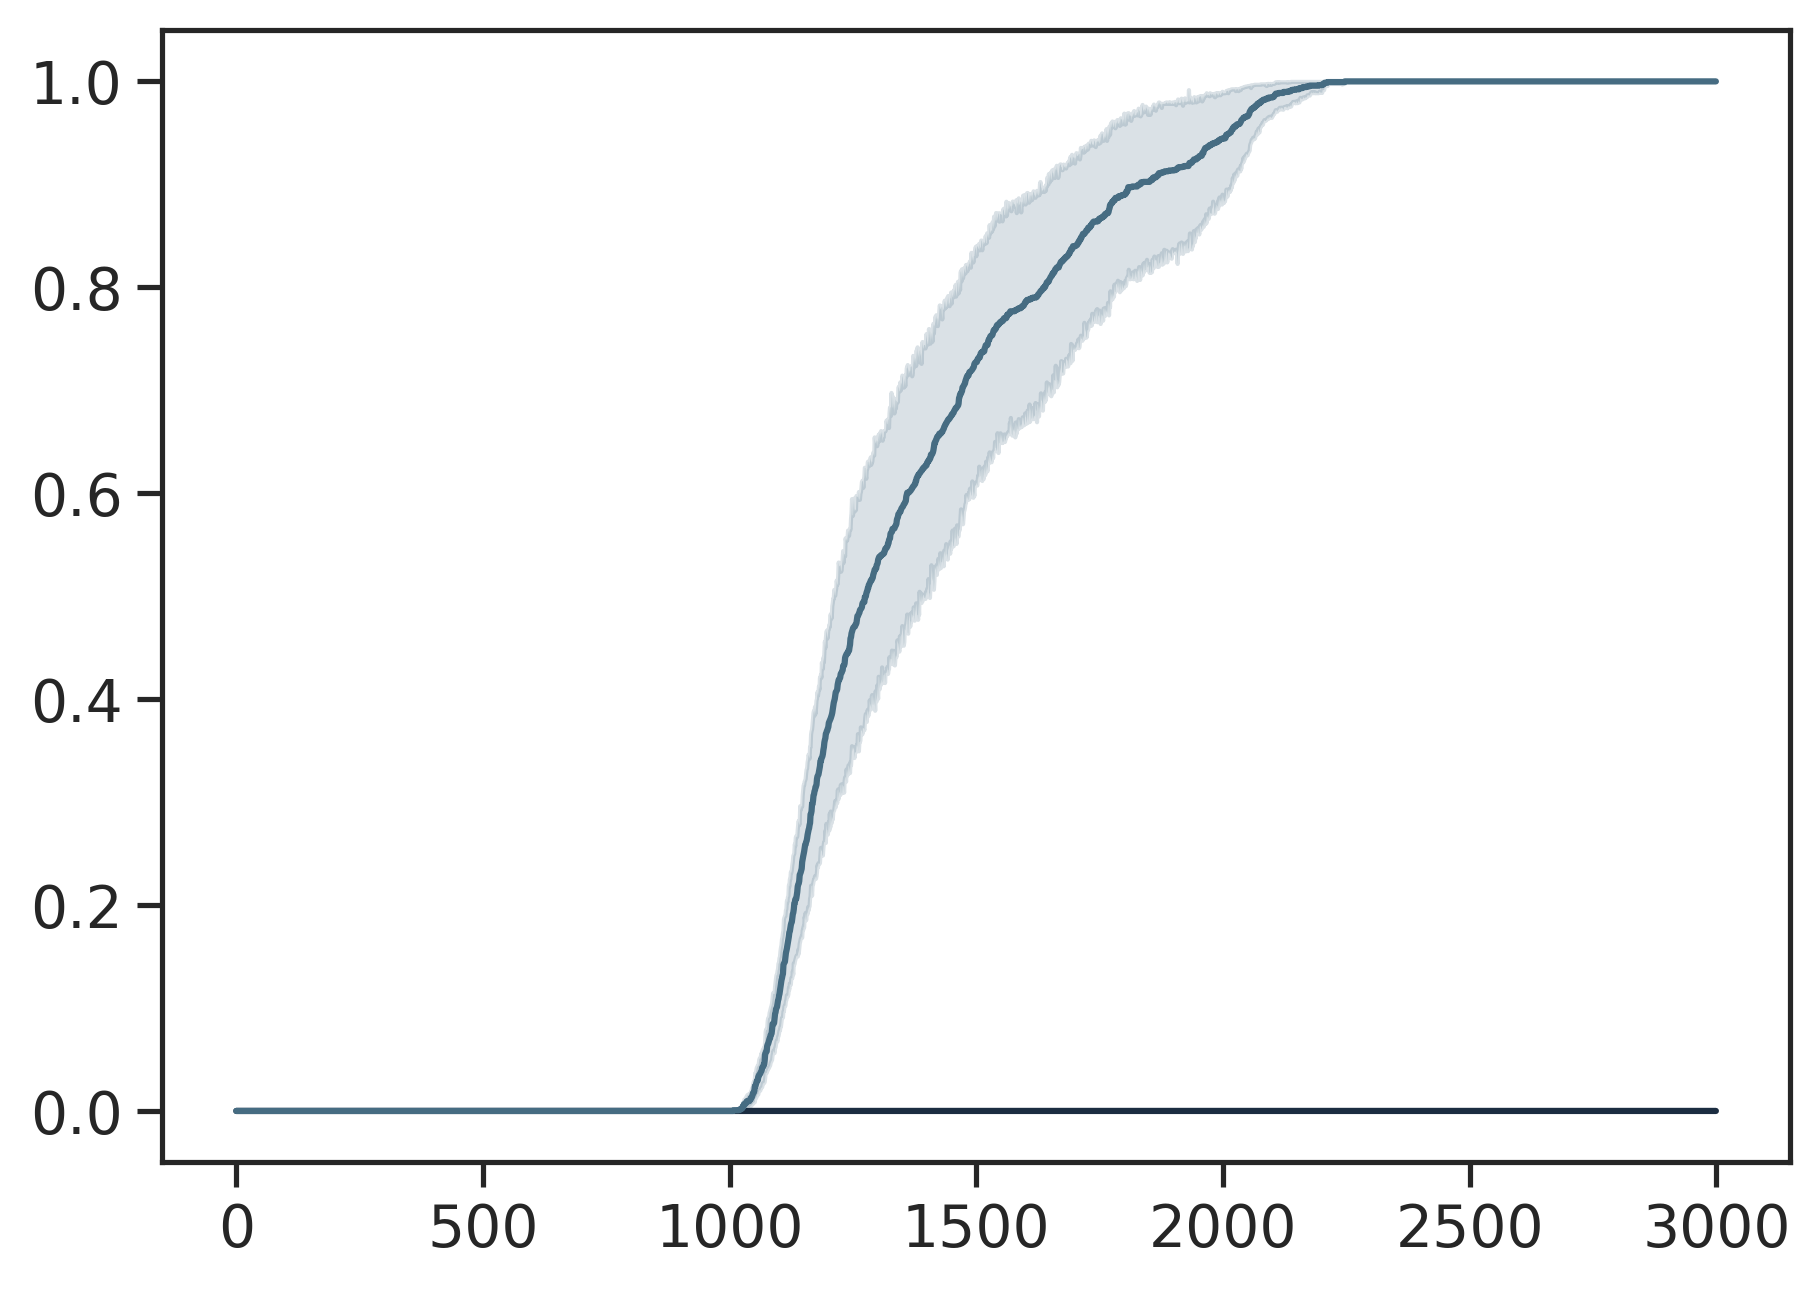

In [99]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_rec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette)
    plt.legend(title='Min Reputation', loc='lower right')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

/tmp/ipykernel_5922/3836423237.py:6: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette)


min_rep_prec_over_time.pngDone


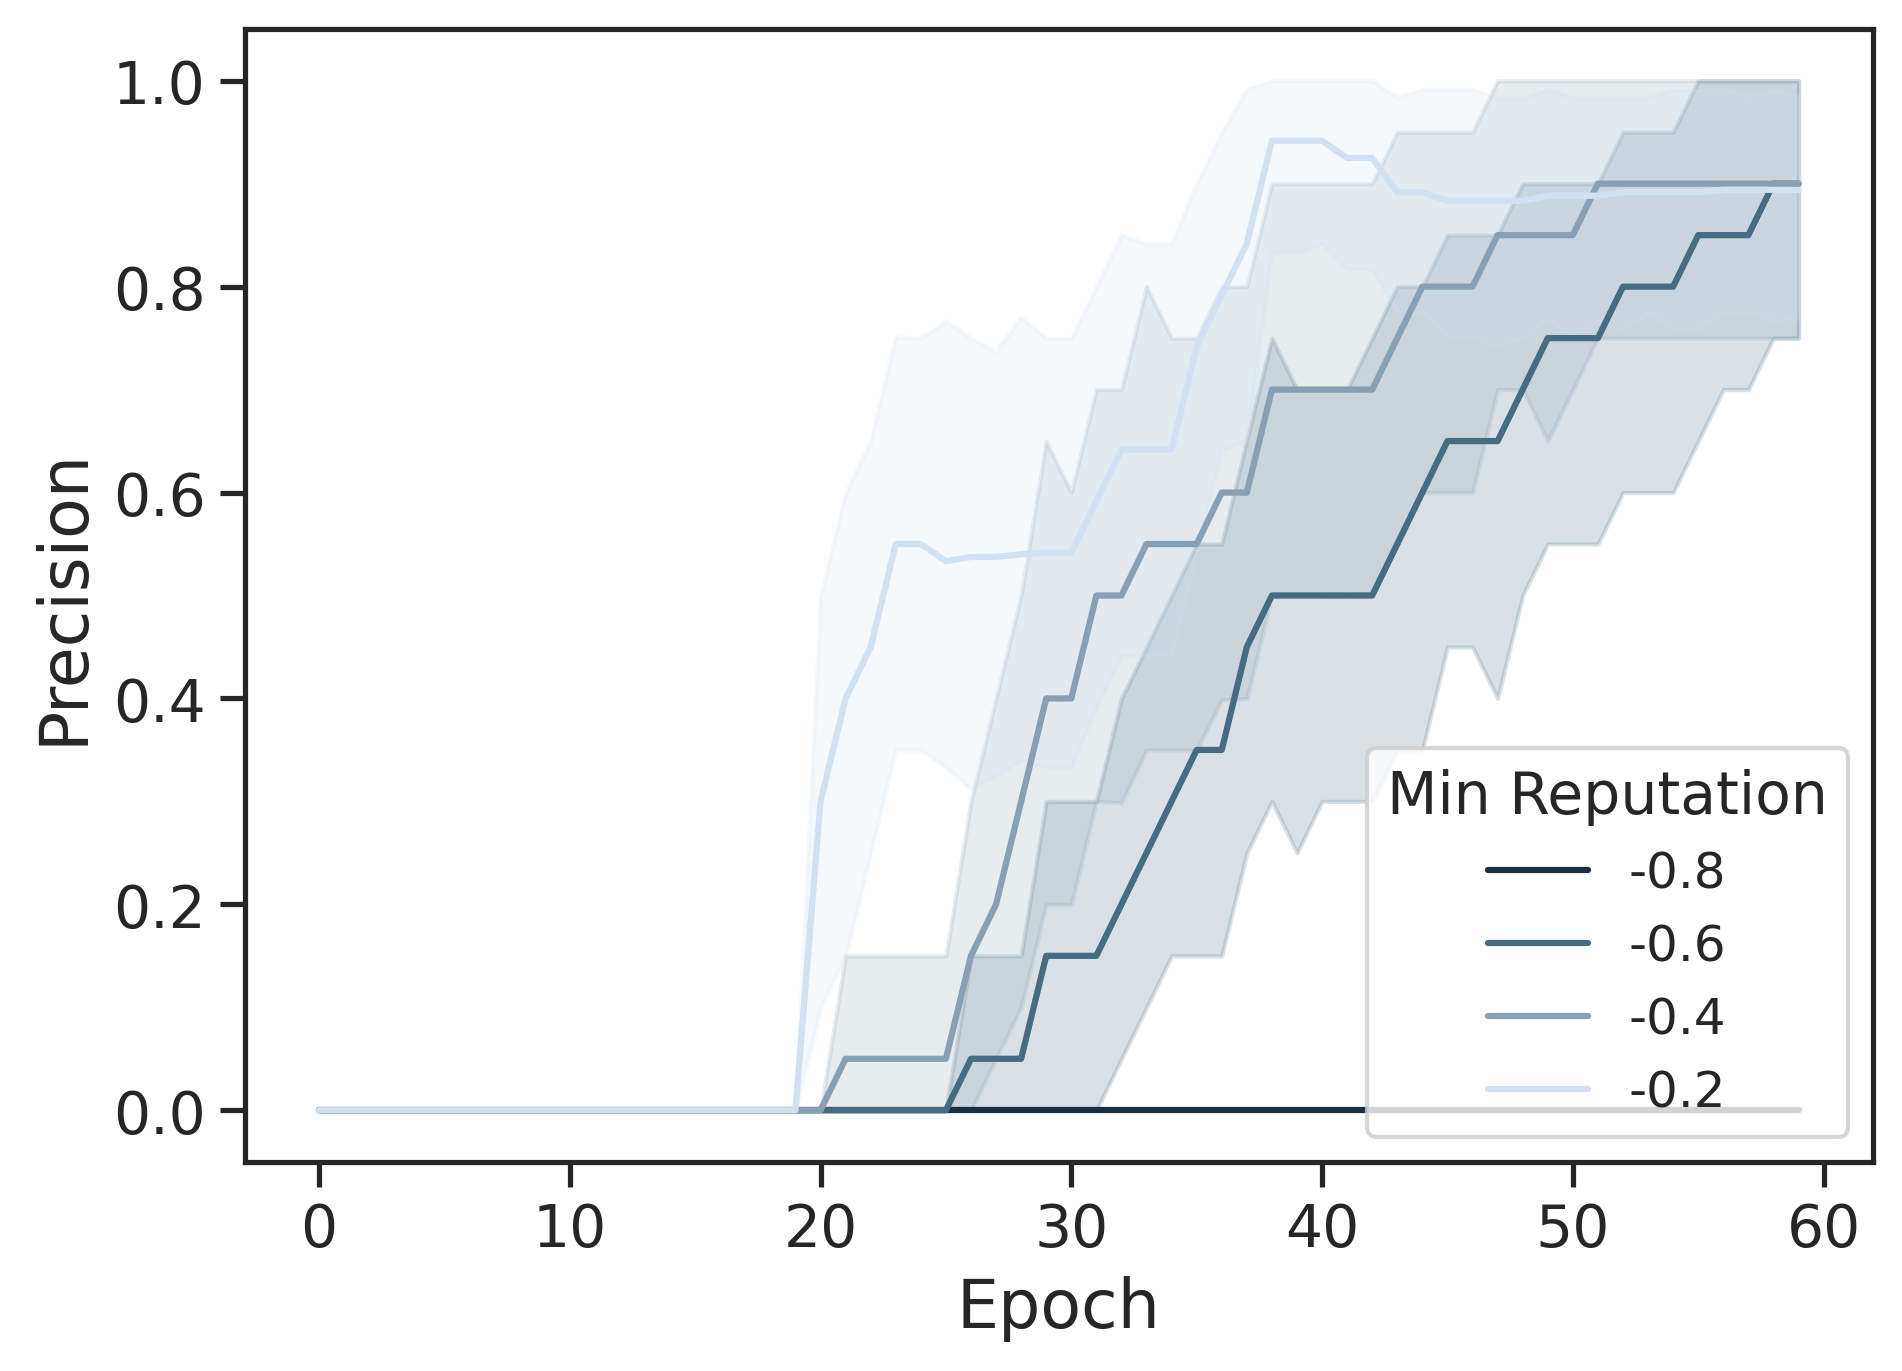

In [50]:
# PLOT 1 - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette)
    plt.legend(title='Min Reputation', loc='lower right')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [51]:
# Dataset only with threshold = -0.4
df_def_4 = df_def.drop(df_def[(df_def.rep_min != -0.4)].index)

Doing min_rep_rec_over_nummal.png
min_rep_rec_over_nummal.pngDone


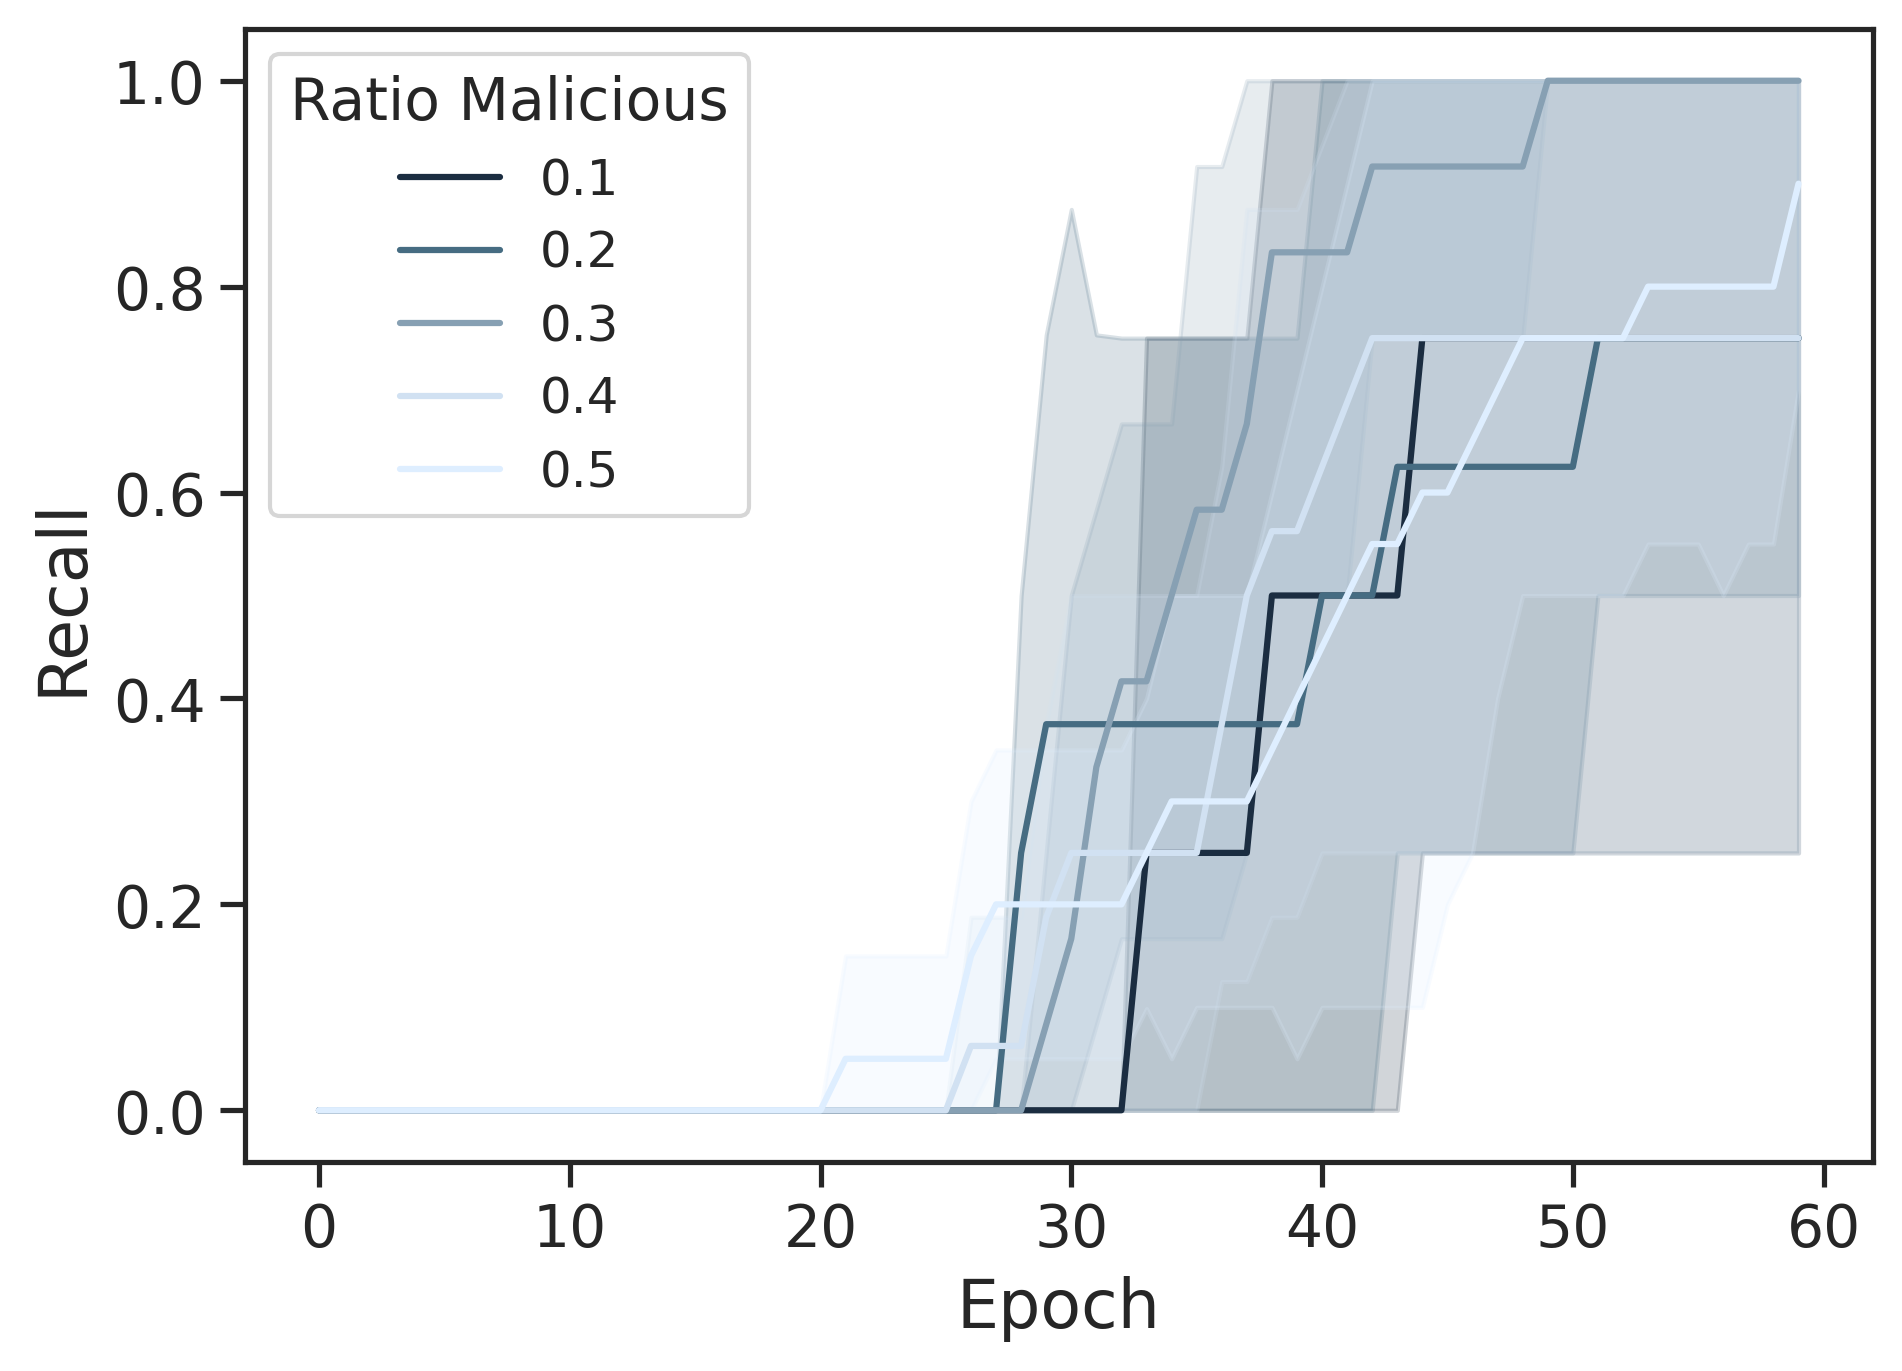

In [52]:
# PLOT 2 - RECALL OVER NUM MALICIOUS
# How many malicious sources I manage to kick out over time.
img_name = "min_rep_rec_over_nummal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Recall', hue='ratio_malign', palette=zonia_palette)
    plt.legend(title='Ratio Malicious', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing min_rep_prec_over_nummal.png
min_rep_prec_over_nummal.pngDone


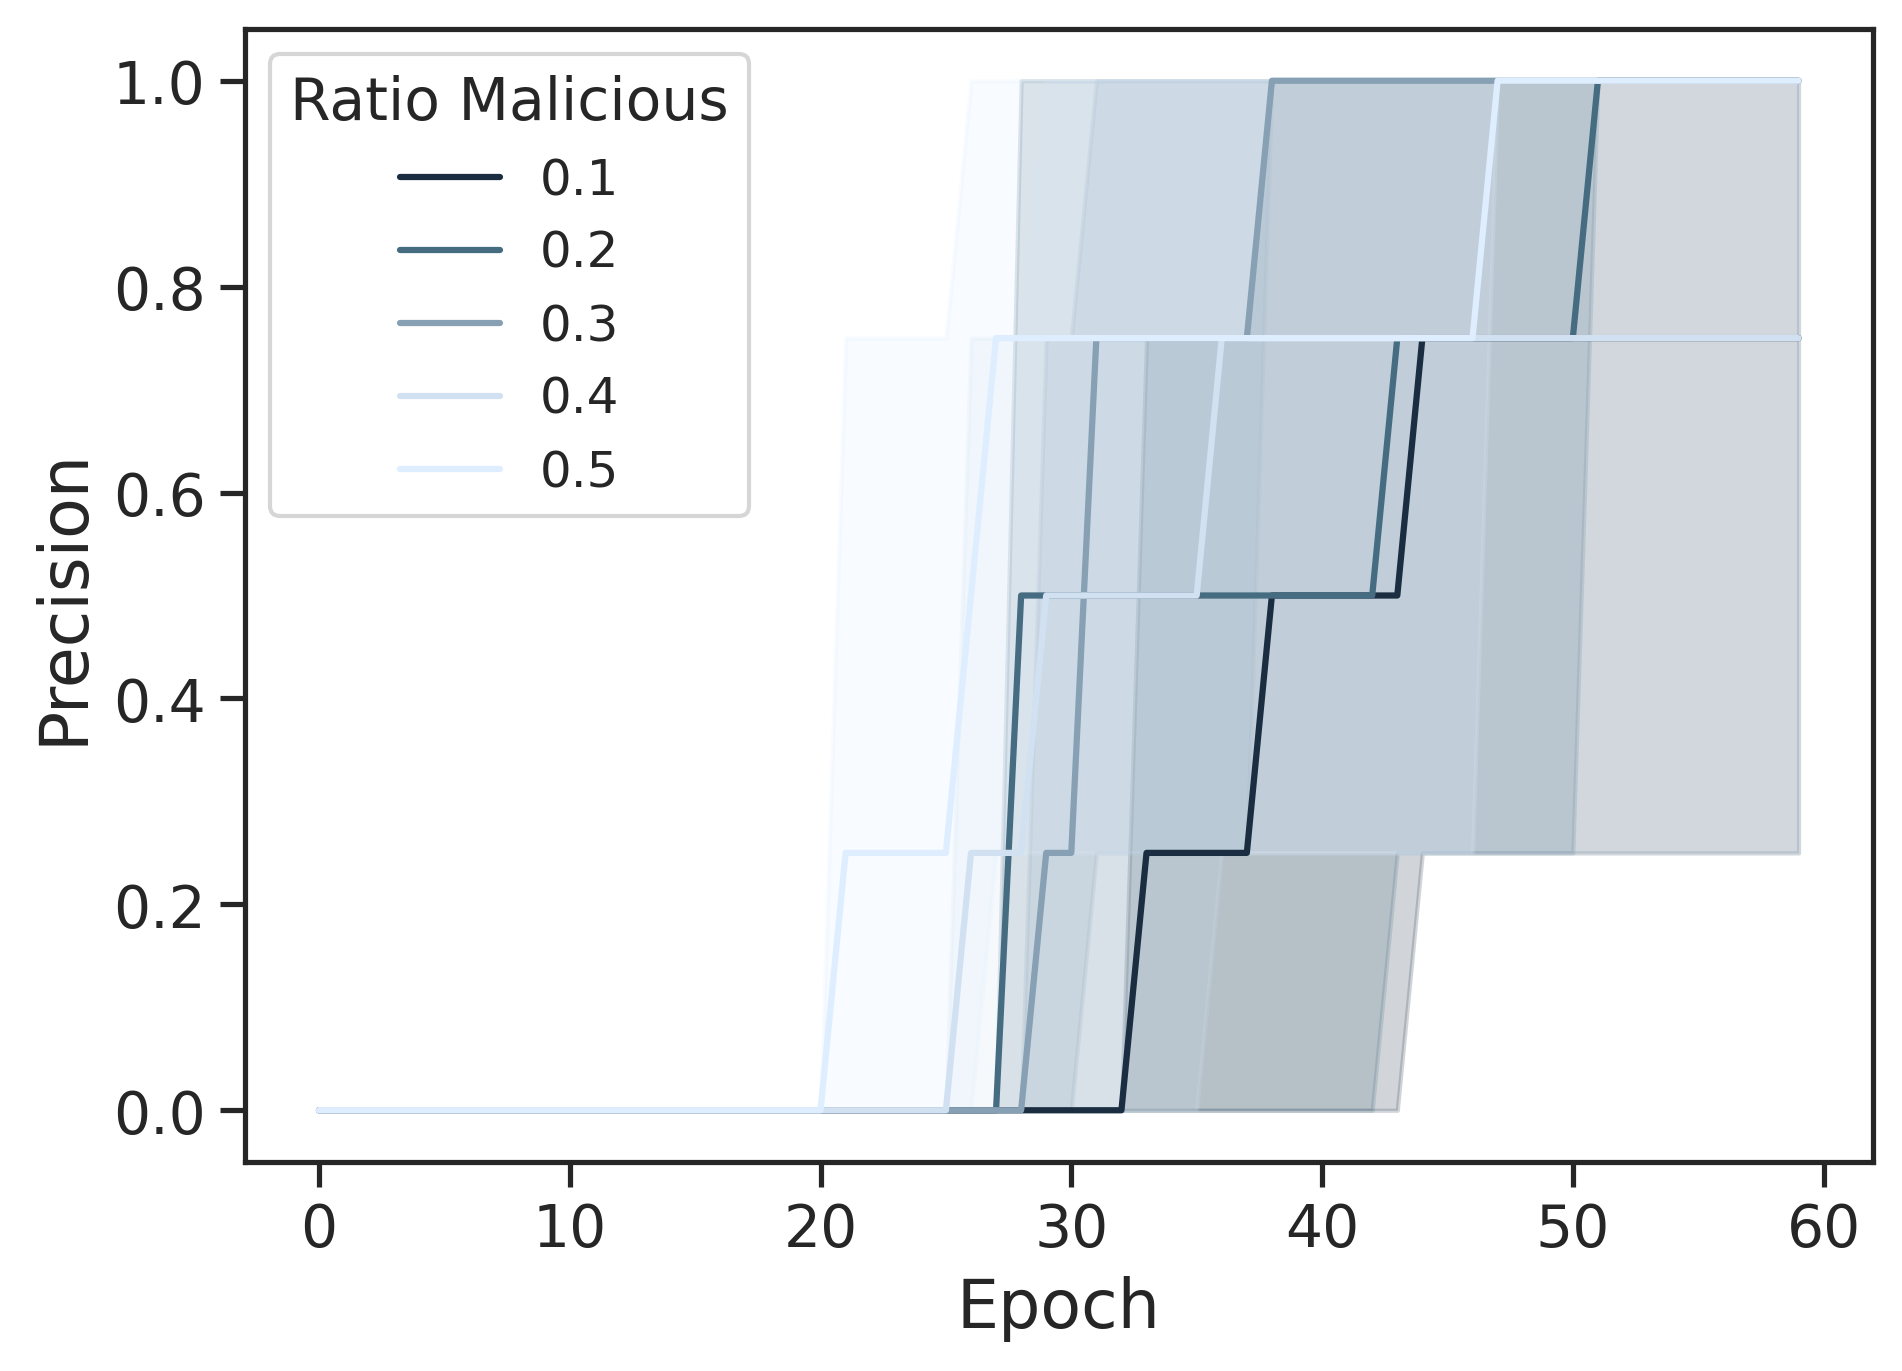

In [53]:
# PLOT 2 - PRECISION OVER NUM MALICIOUS
# How many malicious sources I manage to kick out over time.
img_name = "min_rep_prec_over_nummal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Precision', hue='ratio_malign', palette=zonia_palette)
    plt.legend(title='Ratio Malicious', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing rep_ben_mal.png
rep_ben_mal.pngDone


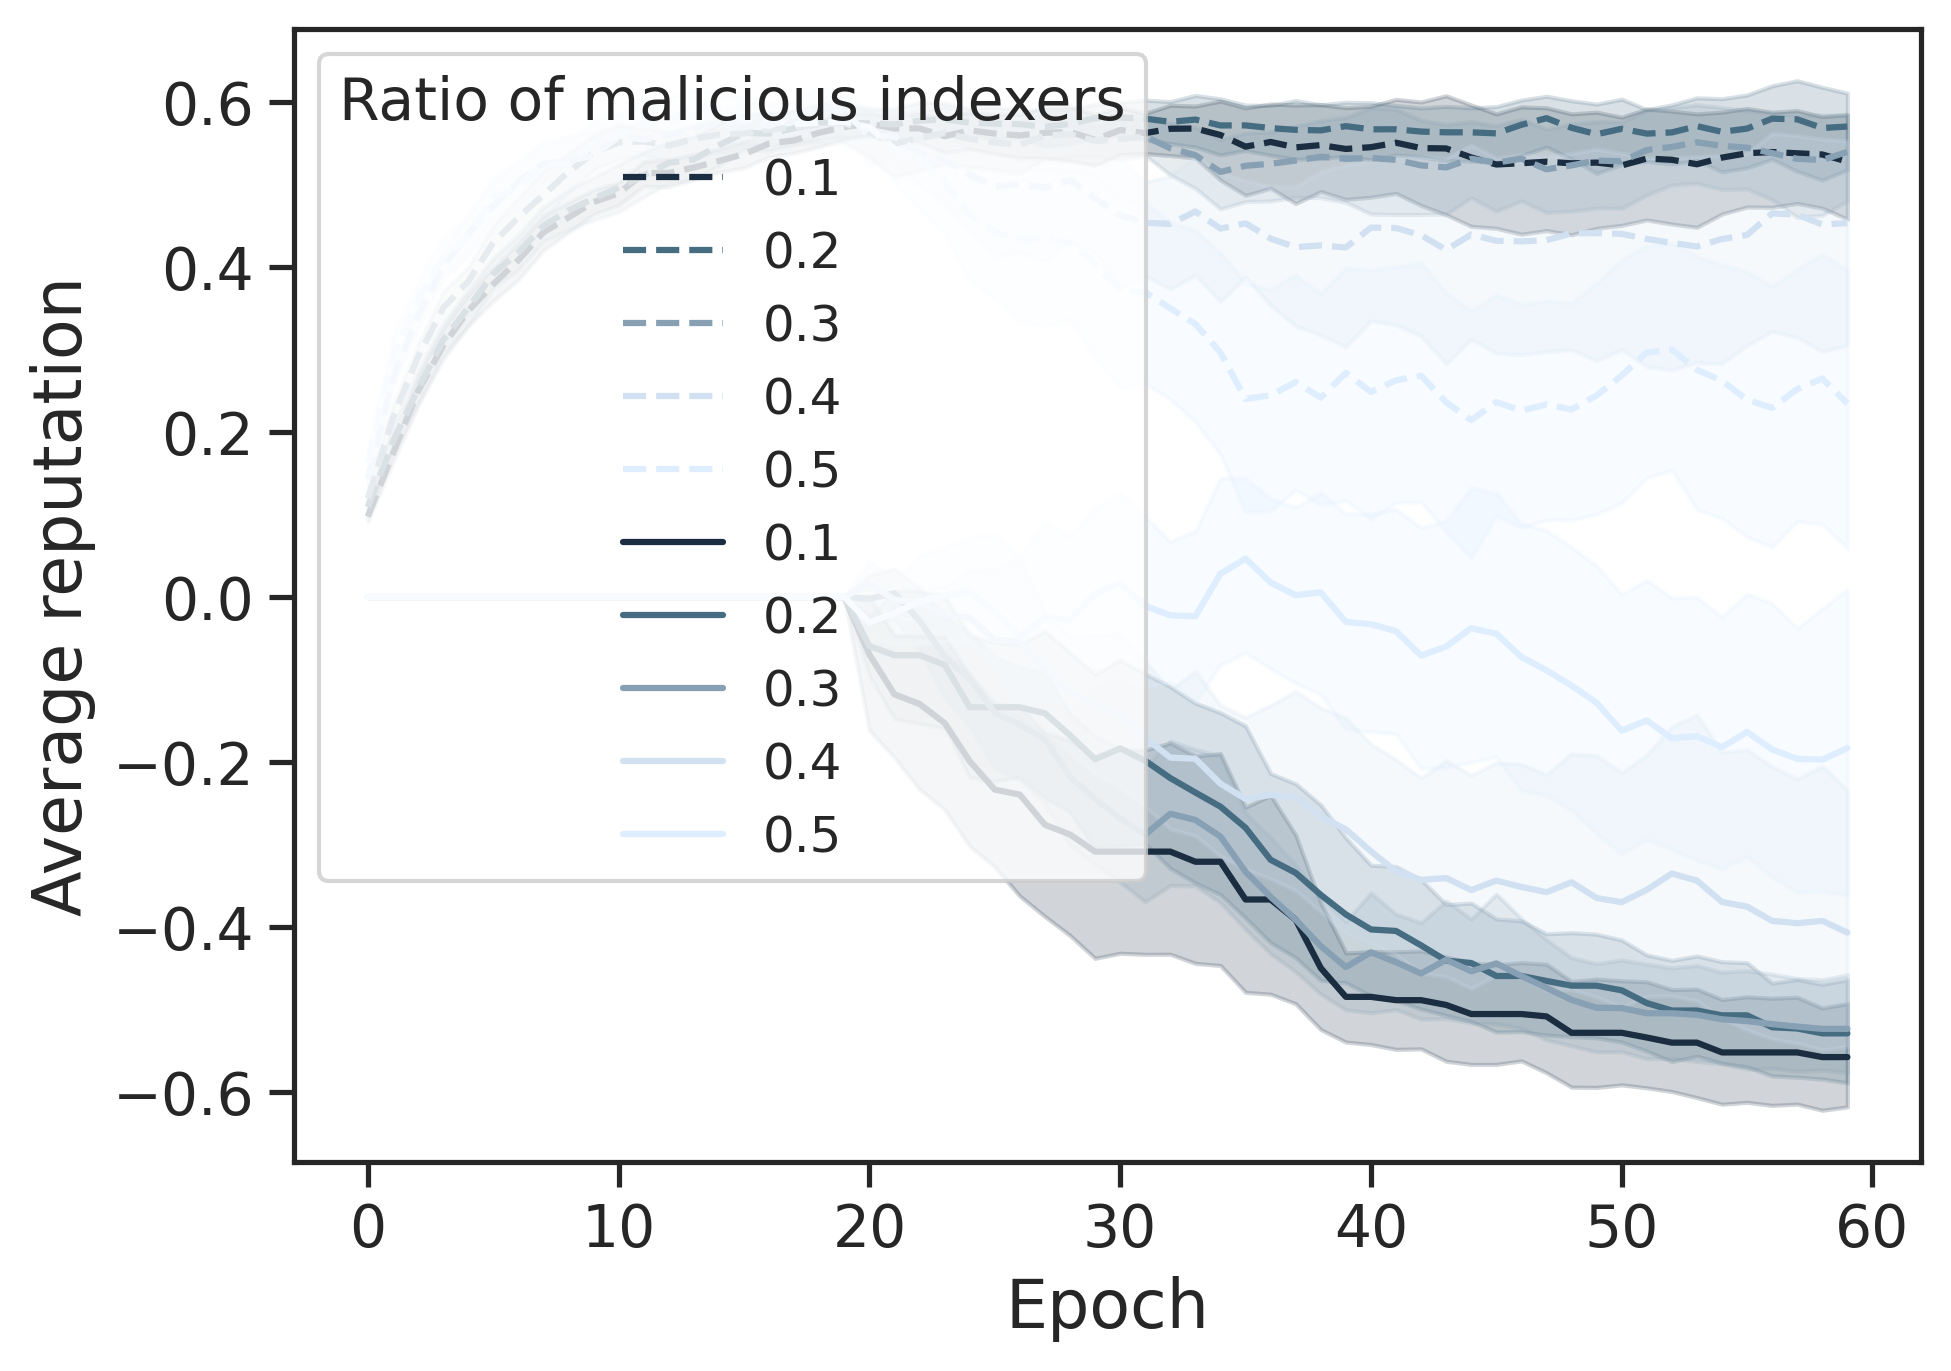

In [54]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_ben_mal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    ab = sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign', palette=zonia_palette)
    for l in ab.lines:
        l.set_linestyle("--")
    aa = sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette)

    plt.legend(title='Ratio of malicious indexers', loc='upper left')
    plt.ylabel("Average reputation", fontsize=16)
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [55]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_malign.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette)
    plt.ylabel('Average reputation (malicious indexers)', fontsize=16)
    plt.legend(title='Ratio of malicious indexers', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [56]:
# PLOT 3 - IMPACT OF ALPHA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_alpha.png"
if not _DISCARD_:
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='alpha', style='Arrival', markers=True)
    plt.legend(title='Arrival rate', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [57]:
# PLOT 3 - IMPACT OF BETA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_beta.png"
if not _DISCARD_:
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='beta', style='Arrival', markers=True)
    plt.legend(title='Legend', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [58]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [59]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [60]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

img_name = "algorithm_comparison_bursty.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print("Doing " + img_name)
    ax = sns.countplot(data=df_good, x='ratio_malign', hue='Algorithm')
    for i in ax.containers:
        ax.bar_label(i, fontsize=5)
    plt.legend(title='Algorithm', loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3,
    labels=['Consensus', 'Ranking', 'Reputation'])
    ax.set_xlabel('Ratio of Malignous Sources', fontsize=16)
    ax.set_ylabel('Ratio of Accurate Responses', fontsize=16)

    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


In [107]:
print("Doing the bars...")
df_bar = df_goodo.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)


df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()


Doing the bars...


Doing desmo_accuracy.png


/tmp/ipykernel_5922/3450402740.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_5922/3450402740.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()


desmo_accuracy.png Done!


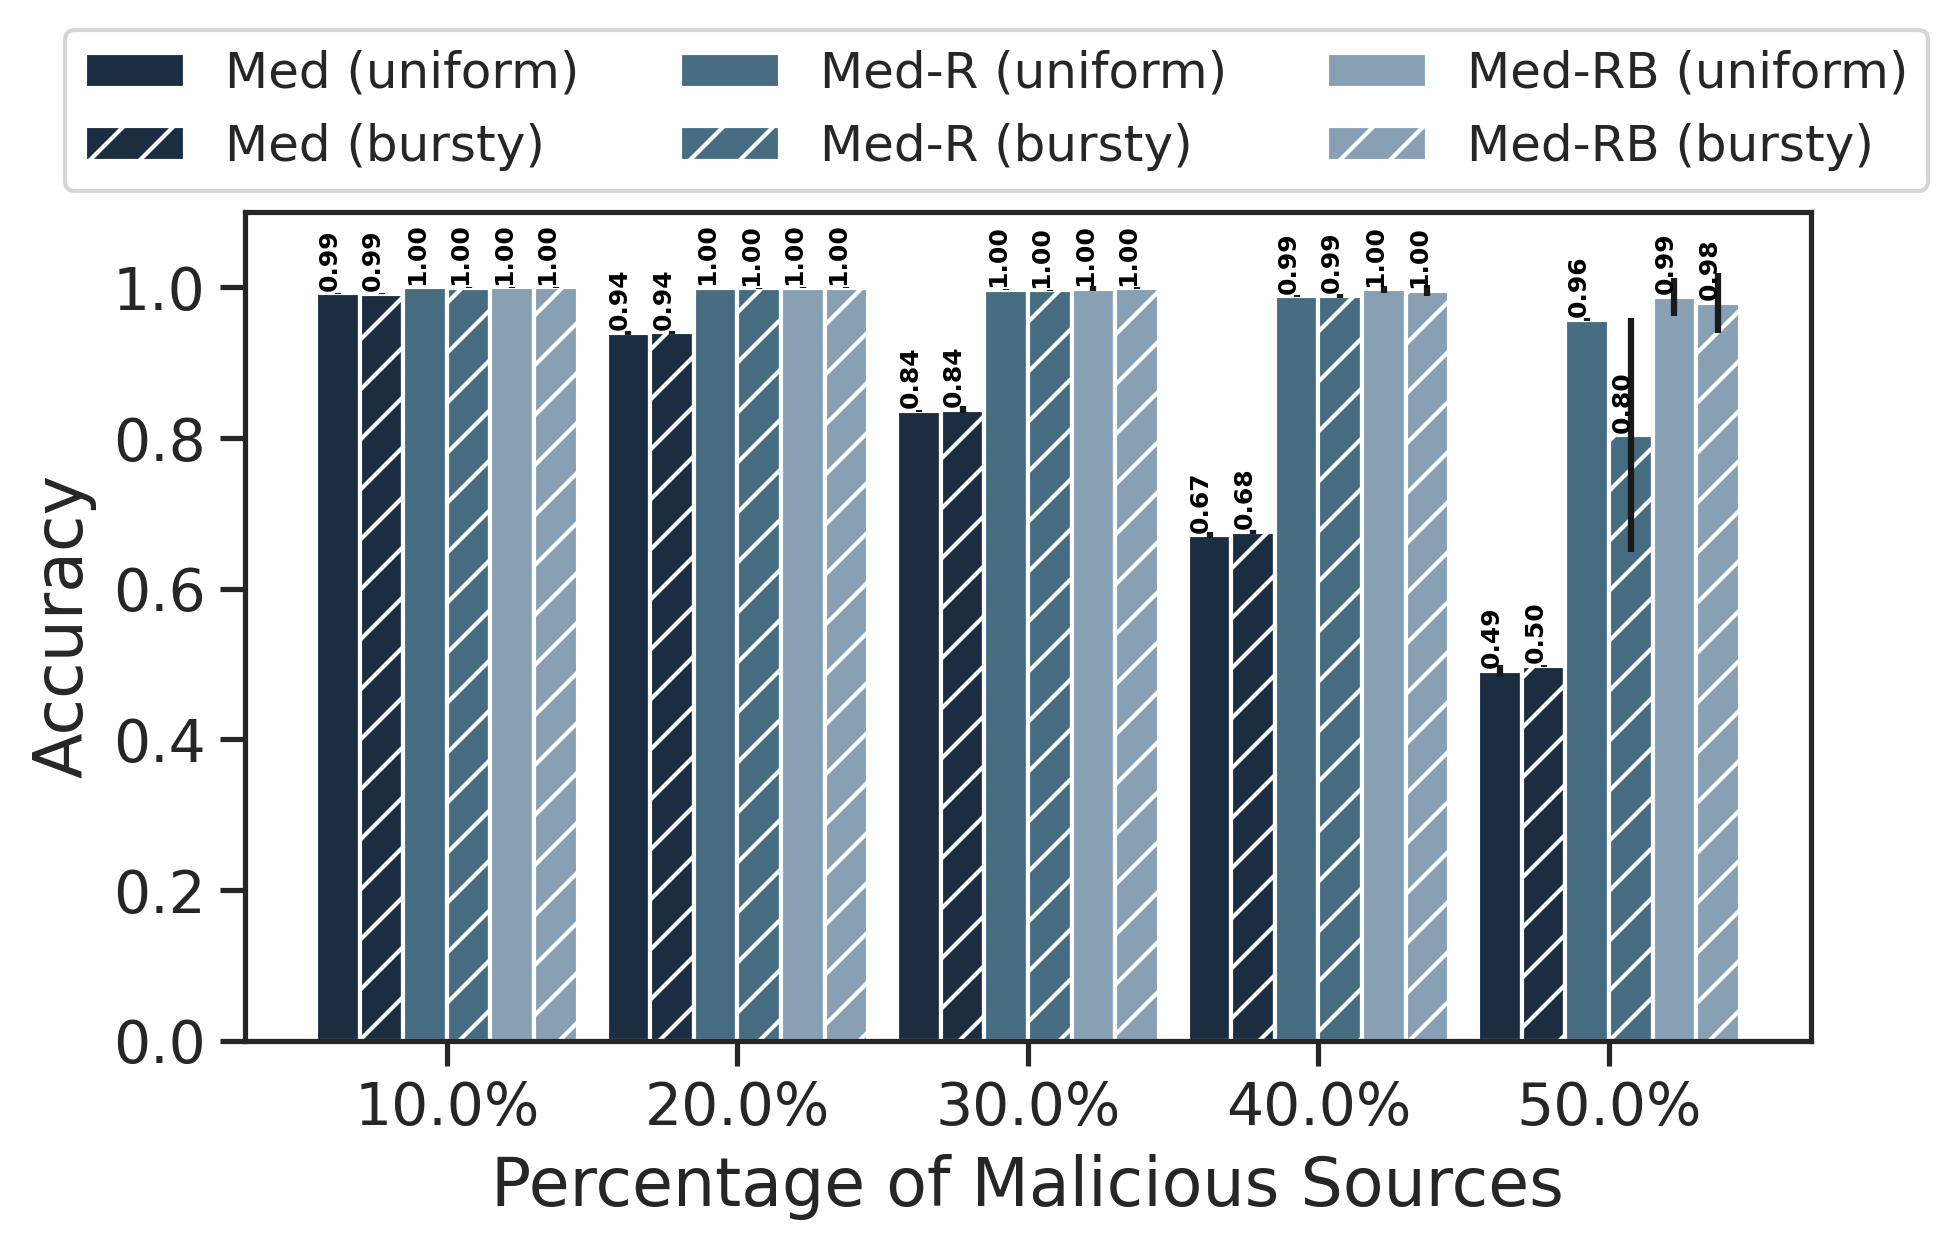

In [108]:
img_name = "desmo_accuracy.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('Percentage of Malicious Sources', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.25), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

In [ ]:
print("Doing the bars...")
df_bar = df_goodo2.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)


df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_tail.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('Percentage of Malicious Sources', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.25), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

[0.69375    0.60416667 0.49895833 0.81354167 0.7        0.52291667
 0.88229167 0.76770833 0.615625   0.96770833 0.853125   0.71770833
 1.         0.91770833 0.740625  ]


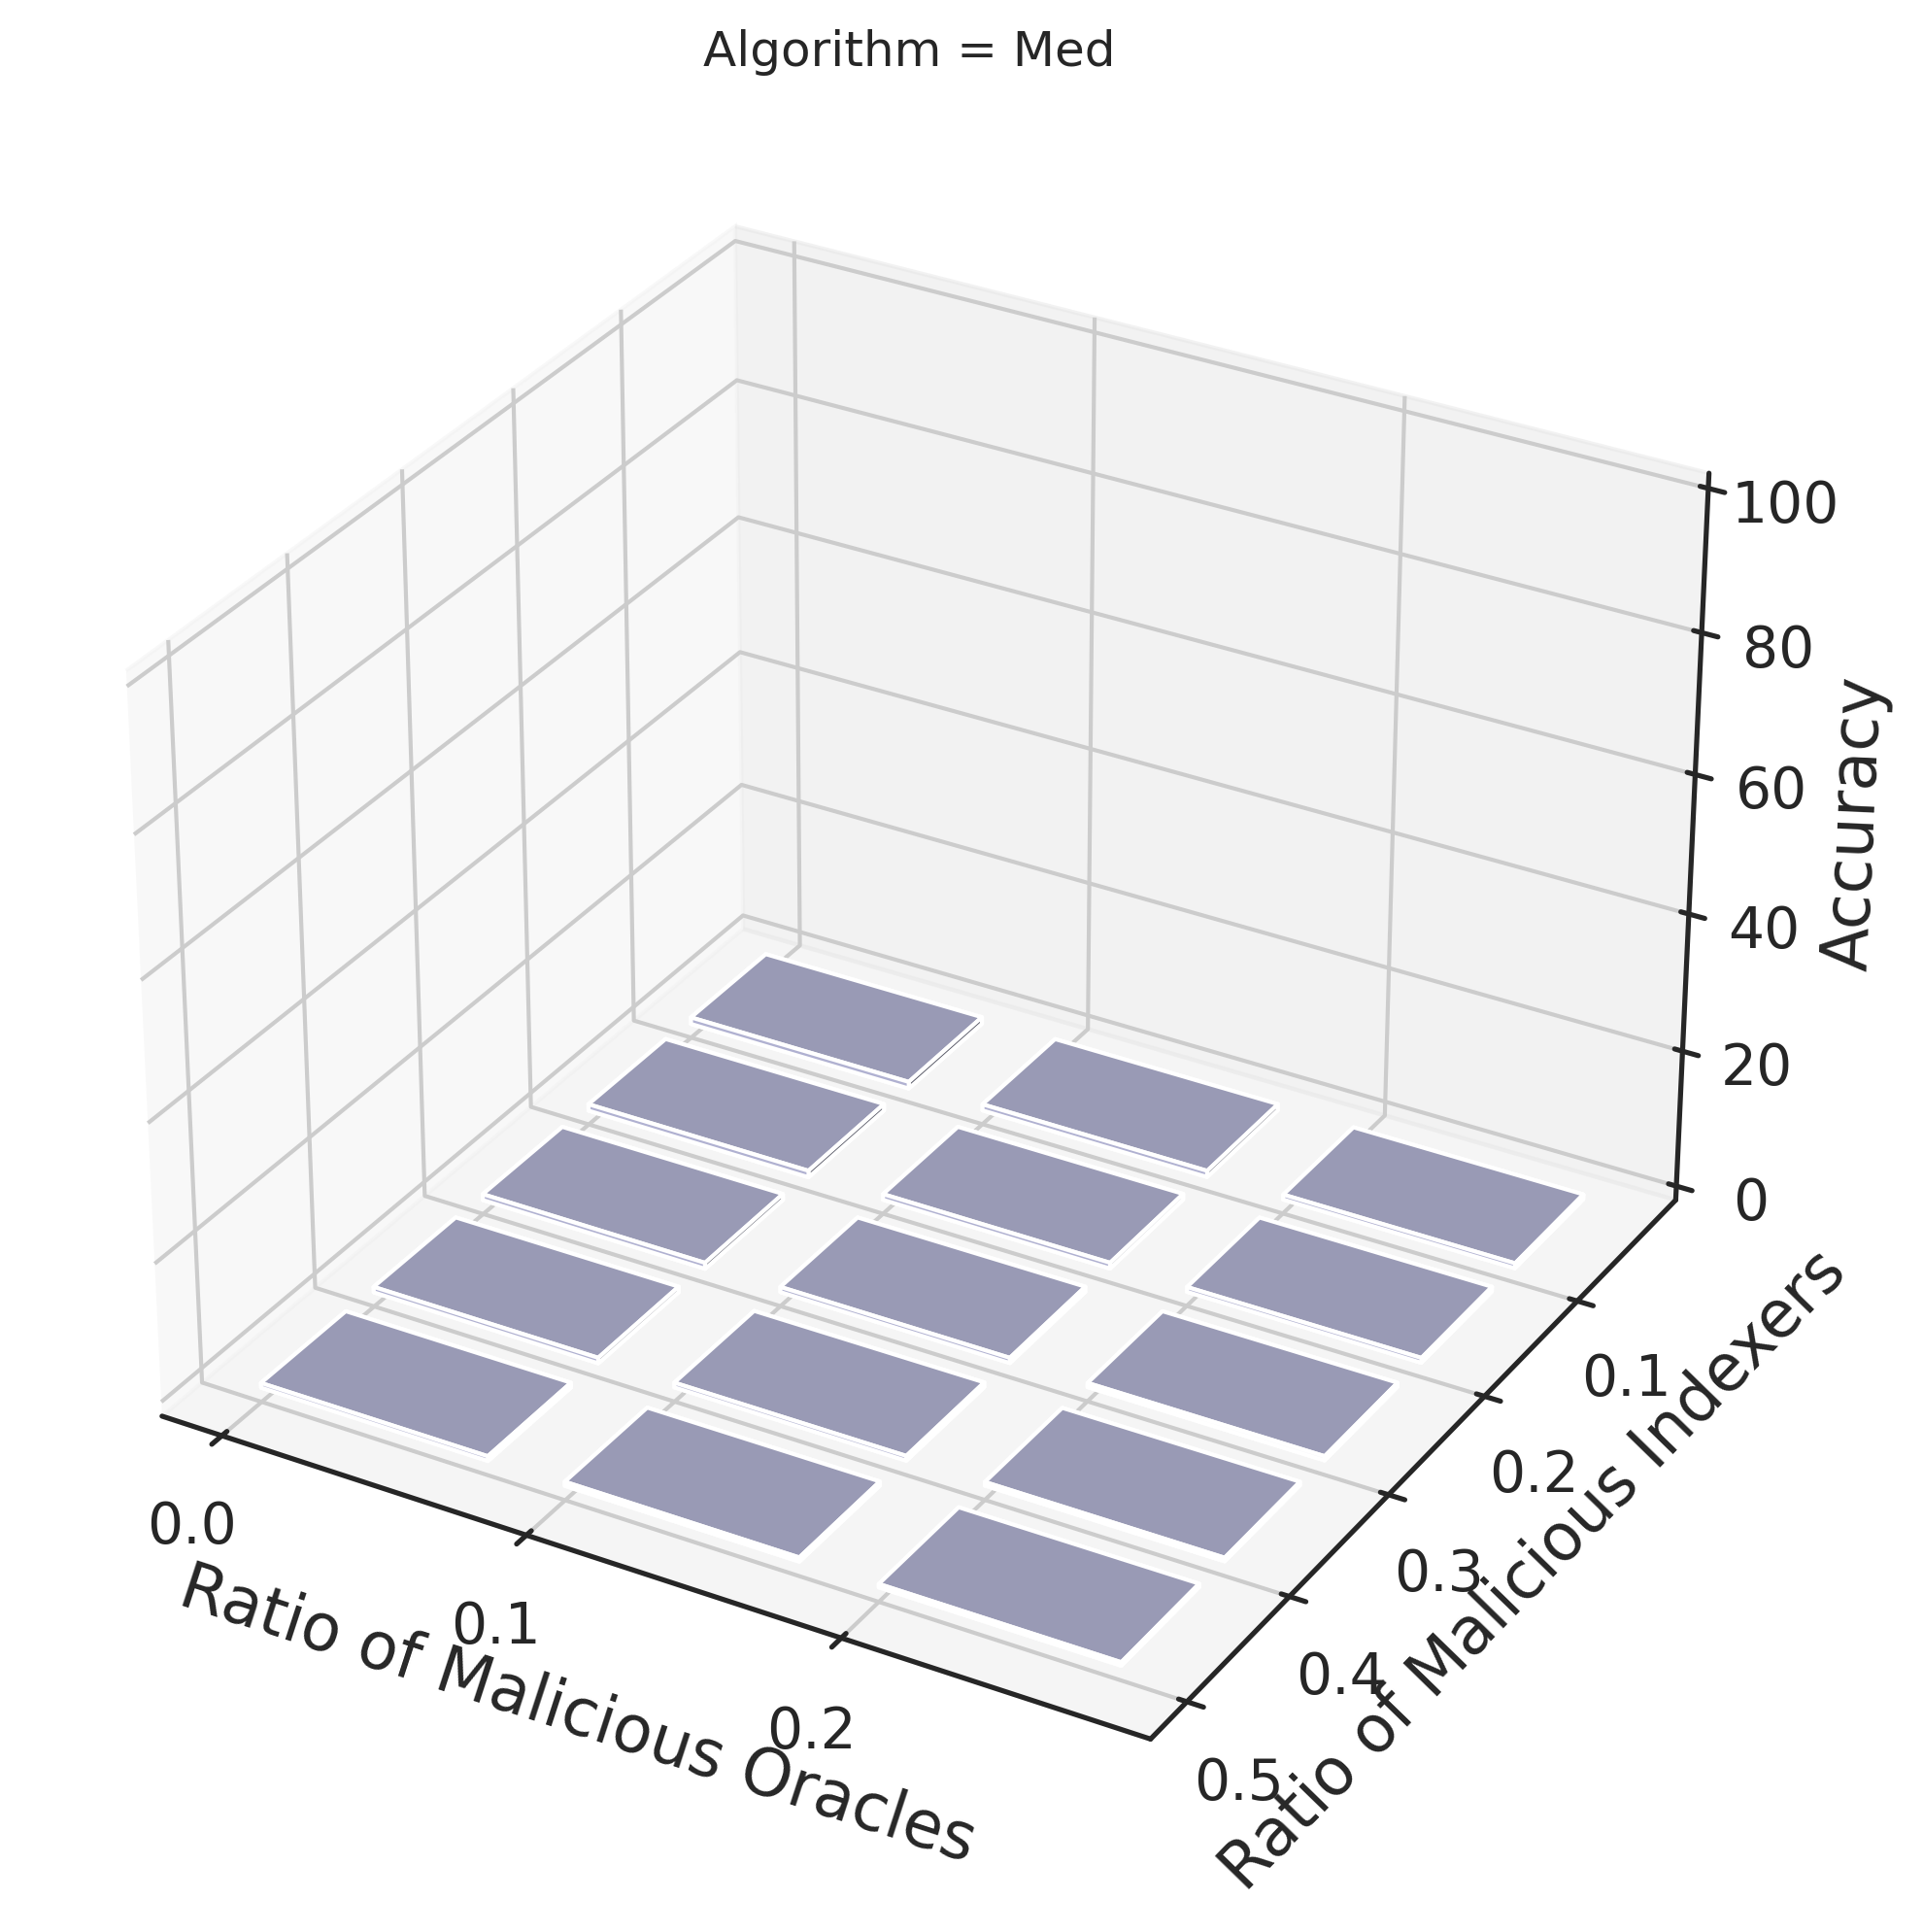

In [14]:
img_name = "3d_accuracy_1.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 0)].index)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
    ax.set_zlim(0, 100)

    ax.set_xticks(np.arange(len(xvals)))
    ax.set_yticks(np.arange(len(yvals)))
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)

    ax.set_xlabel('Ratio of Malicious Oracles')
    ax.set_ylabel('Ratio of Malicious Indexers')
    ax.set_zlabel('Accuracy')
    plt.title('Algorithm = Med')
    plt.savefig(img_name, dpi=200)

       Epoch  sources  malign  ban_sources  ban_malign  consensus  rep_benign  \
60         0       10       2            0           0  25.001298    0.103643   
61         1       10       2            0           0  25.299974    0.191588   
62         2       10       2            0           0  24.821047    0.246720   
63         3       10       2            0           0  24.494724    0.275642   
64         4       10       2            0           0  24.902565    0.287803   
...      ...      ...     ...          ...         ...        ...         ...   
42876     55       10       3            0           0  24.843006    0.093801   
42877     56       10       3            0           0  25.268623    0.257766   
42878     57       10       3            0           0  23.817942    0.302971   
42879     58       10       3            0           0  24.987229    0.403848   
42880     59       10       3            0           0  24.336146    0.340258   

       rep_malign  rep_min 

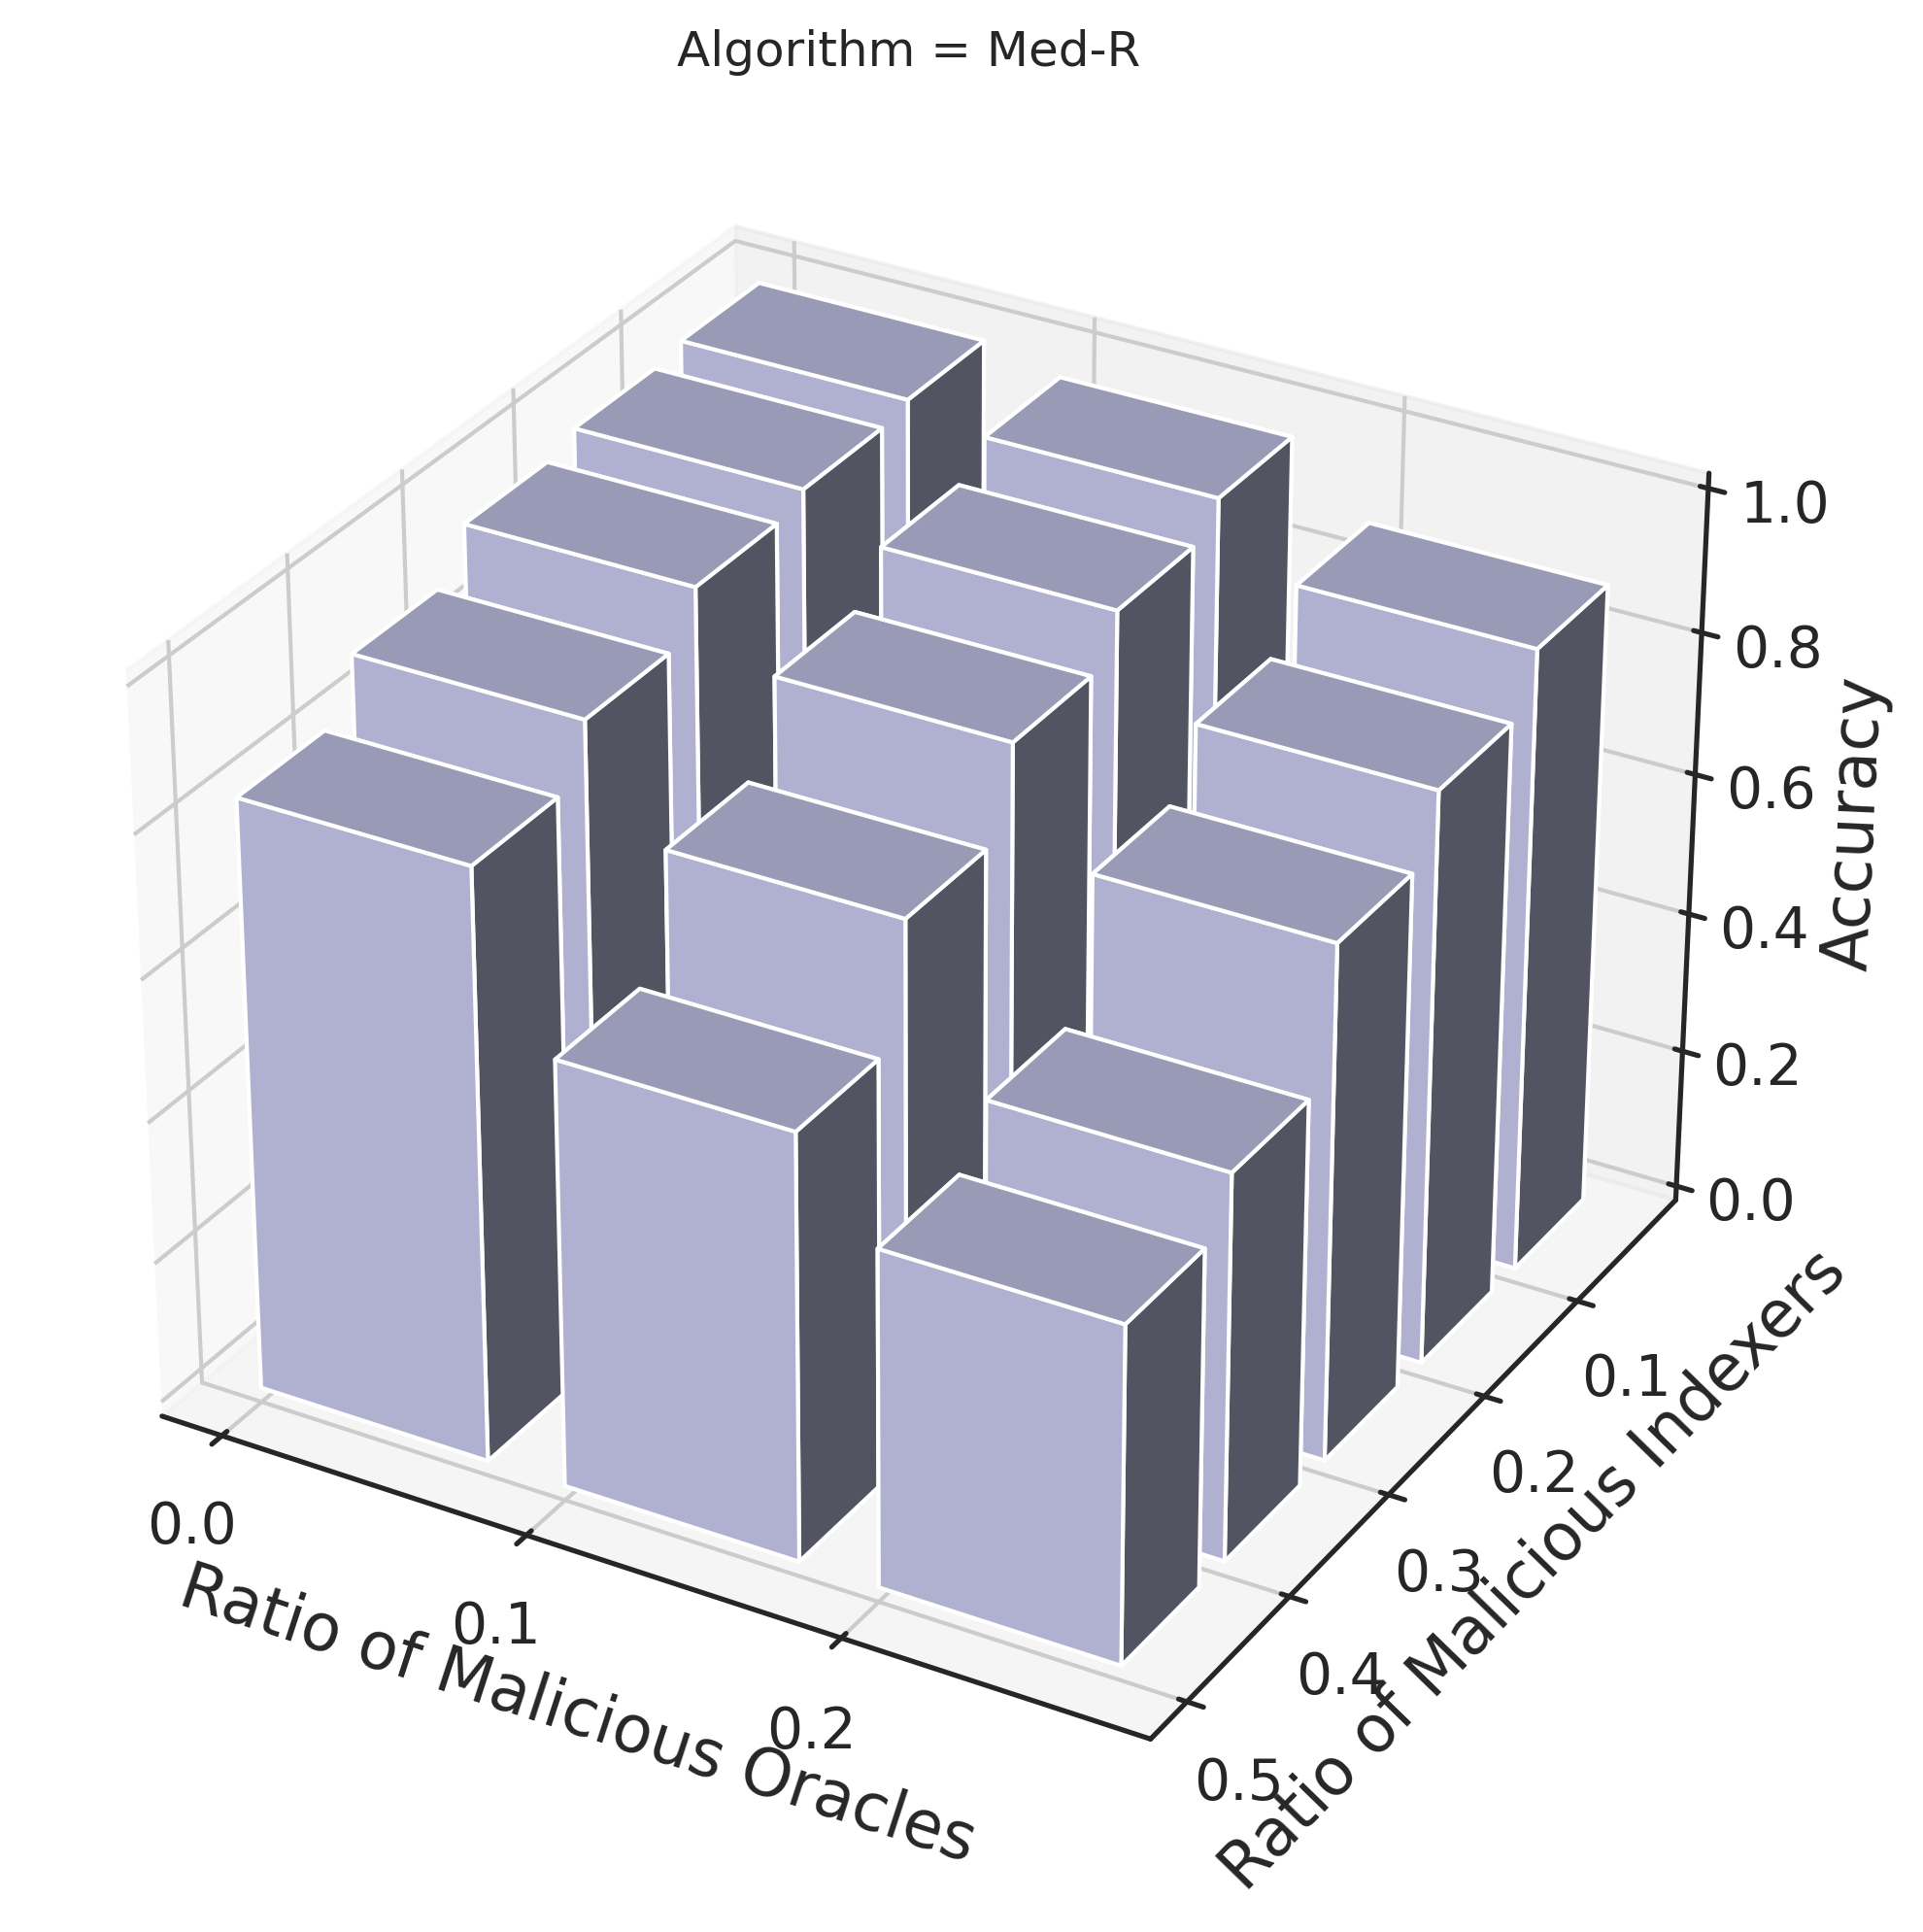

In [15]:
img_name = "3d_accuracy_2.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 1)].index)

    print(this_df)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
            print(xvals[_x], yvals[_y], values[_x][_y])
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    ax.set_xticks(np.arange(len(xvals)))
    ax.set_yticks(np.arange(len(yvals)))
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)
    ax.set_zlim(0, 1)
    ax.set_xlabel('Ratio of Malicious Oracles')
    ax.set_ylabel('Ratio of Malicious Indexers')
    ax.set_zlabel('Accuracy')
    plt.title('Algorithm = Med-R')
    plt.savefig(img_name, dpi=200)

       Epoch  sources  malign  ban_sources  ban_malign  consensus  rep_benign  \
180        0       10       5            0           0  24.556214    0.097109   
181        1       10       5            0           0  24.690058    0.102110   
182        2       10       5            0           0  24.845935    0.091217   
183        3       10       5            0           0  25.114120    0.248133   
184        4       10       5            0           0  24.207908    0.219260   
...      ...      ...     ...          ...         ...        ...         ...   
43116     55       10       3            0           0  18.848536    0.126248   
43117     56       10       3            0           0  24.921781    0.245194   
43118     57       10       3            0           0  10.075275    0.210499   
43119     58       10       3            0           0  16.882745    0.091885   
43120     59       10       3            0           0  24.546149    0.161113   

       rep_malign  rep_min 

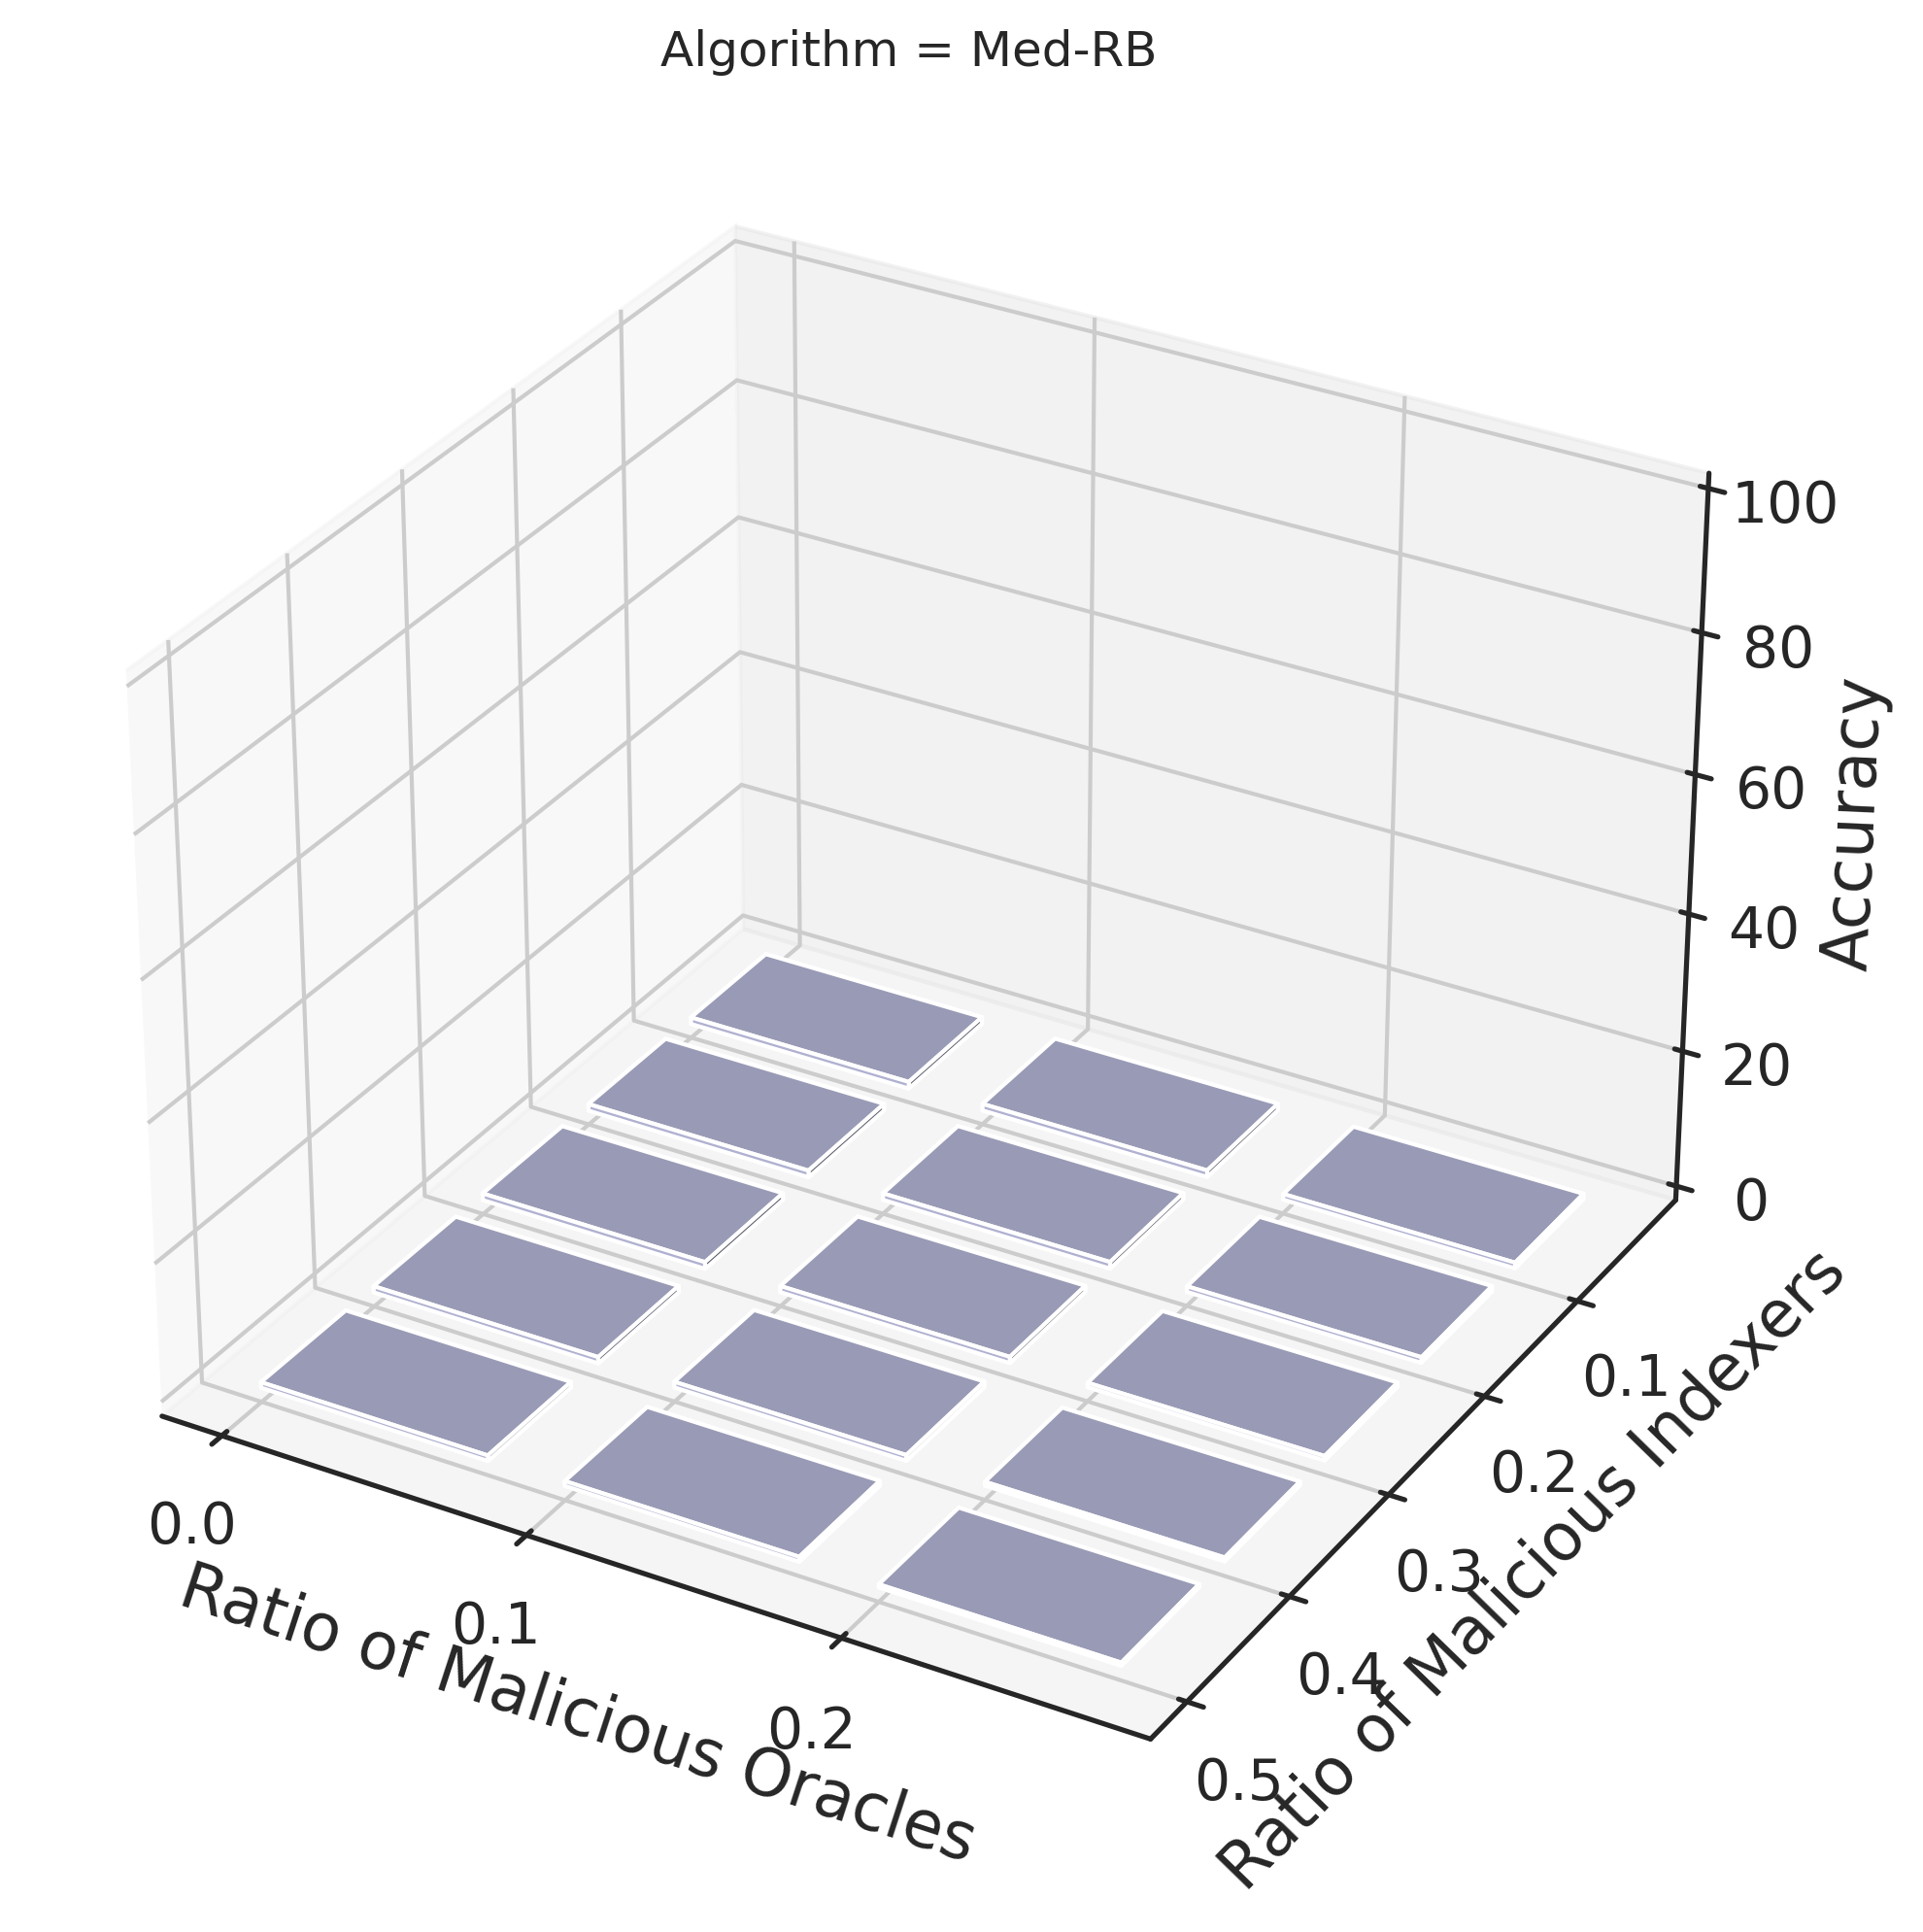

In [10]:
img_name = "3d_accuracy_3.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 2)].index)

    print(this_df)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
            print(xvals[_x], yvals[_y], values[_x][_y])
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
    ax.set_zlim(0, 100)

    ax.set_xticks(np.arange(len(xvals)))
    ax.set_yticks(np.arange(len(yvals)))
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)

    ax.set_xlabel('Ratio of Malicious Oracles')
    ax.set_ylabel('Ratio of Malicious Indexers')
    ax.set_zlabel('Accuracy')
    plt.title('Algorithm = Med-RB')
    plt.savefig(img_name, dpi=200)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])